In [1]:
!pip install -U langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 7.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: openai
    Found existing installation: openai 1.68.2
    Uninstalling openai-1.68.2:
      Successfully uninstalled openai-1.68.2
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.83
    Uninstalling langchain-core-0.3.83:
      Successfully uninstalled langchain-core-0.3.83
  Attempting uninstall: langchain-openai
    Found existing installation: langchain-openai 0.3.10
    Uninstalling langchain-openai-0.3.10:
      Successfully uninstalled langchain-openai-0.3.10
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.3.2

In [2]:
%%capture
!pip install langgraph==0.3.34 langchain-openai==0.3.14 langchainhub==0.1.21 langchain==0.3.24 pygraphviz==1.14 langchain-community==0.3.23

In [7]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
OPENAI_ORG_ID = os.getenv("OPENAI_ORG_ID", "")

# Model Configuration
DEFAULT_MODEL = os.getenv("DEFAULT_MODEL", "gpt-3.5-turbo")
TEMPERATURE = float(os.getenv("TEMPERATURE", "0.7"))
MAX_TOKENS = int(os.getenv("MAX_TOKENS", "500"))
WATSON_URL = os.getenv("IBM_URL_END_POINT")
PROJECT_ID = os.getenv("IBM_PROJECT_ID")
IBM_API_KEY = os.getenv("IBM_API_KEY")
TAVILY_KEY = os.getenv("TAVILY_API_KEY")

In [9]:
import warnings 
warnings.filterwarnings('ignore')

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools import tool
import os
import json

os.environ["TAVILY_API_KEY"] = TAVILY_KEY

# Initialize the Tavily search tool
search = TavilySearchResults()

@tool
def search_tool(query: str):
    """
    Search the web for information using Tavily API.

    :param query: The search query string
    :return: Search results related to the query
    """
    return search.invoke(query)

In [10]:
search_tool.invoke("What's the weather like in Tokyo today?")


[{'title': 'Weather for Tokyo, Japan',
  'url': 'https://www.timeanddate.com/weather/japan/tokyo',
  'content': 'timeanddate.com\nFlag for Japan\n\n# Weather in Tokyo, Japan\n\nOvercast.\n\nFeels Like: 62 °F  \nForecast: 69 / 60 °F  \nWind: 20 mph ↑ from South\n\n|  |  |\n --- |\n| Location: | Tokyo |\n| Current Time: | Apr 9, 2026 at 11:22:56 pm |\n| Latest Report: | Apr 9, 2026 at 9:00 pm |\n| Visibility: | 19 mi |\n| Pressure: | 29.97 "Hg |\n| Humidity: | 69% |\n| Dew Point: | 52 °F |\n\nLocation of Tokyo\nLocation\n\n## Upcoming 5 hours\n\n|  |  |  |  |  |  |\n ---  ---  --- |\n| Now | 12:00 am | 1:00 am | 2:00 am | 3:00 am | 4:00 am |\n|  |  |  |  |  |  |\n| 62 °F | 60 °F | 60 °F | 60 °F | 60 °F | 61 °F |\n\nSee more hour-by-hour weather\n\n## Forecast for the next 48 hours [...] | Probability of Precipitation | 0% | 83% | 52% | 37% | 61% | 0% | 0% |\n| Amount of Rain | 0.01" | 0.07" | 0.04" | 0.07" | 0.07" | 0.00" | 0.00" |\n| Amount of Snow | 0.00" | 0.00" | 0.00" | 0.00" | 0.00

In [11]:
@tool
def recommend_clothing(weather: str) -> str:
    """
    Returns a clothing recommendation based on the provided weather description.

    This function examines the input string for specific keywords or temperature indicators 
    (e.g., "snow", "freezing", "rain", "85°F") to suggest appropriate attire. It handles 
    common weather conditions like snow, rain, heat, and cold by providing simple and practical 
    clothing advice.

    :param weather: A brief description of the weather (e.g., "Overcast, 64.9°F")
    :return: A string with clothing recommendations suitable for the weather
    """
    weather = weather.lower()
    if "snow" in weather or "freezing" in weather:
        return "Wear a heavy coat, gloves, and boots."
    elif "rain" in weather or "wet" in weather:
        return "Bring a raincoat and waterproof shoes."
    elif "hot" in weather or "85" in weather:
        return "T-shirt, shorts, and sunscreen recommended."
    elif "cold" in weather or "50" in weather:
        return "Wear a warm jacket or sweater."
    else:
        return "A light jacket should be fine."

In [12]:
tools=[search_tool,recommend_clothing]

tools_by_name={ tool.name:tool for tool in tools}

In [13]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

model = ChatOpenAI(model="gpt-4o-mini")

In [14]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage,SystemMessage

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """
You are a helpful AI assistant that thinks step-by-step and uses tools when needed.

When responding to queries:
1. First, think about what information you need
2. Use available tools if you need current data or specific capabilities  
3. Provide clear, helpful responses based on your reasoning and any tool results

Always explain your thinking process to help users understand your approach.
"""),
    MessagesPlaceholder(variable_name="scratch_pad")
])

In [15]:
model_react=chat_prompt|model.bind_tools(tools)

In [16]:
from typing import (Annotated,Sequence,TypedDict)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    """The state of the agent."""

    # add_messages is a reducer
    # See https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [17]:
# Example conversation flow:
state: AgentState = {"messages": []}

# append a message using the reducer properly
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Hi")])
print("After greeting:", state["messages"])

# add another message (e.g. a question)
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Weather in NYC?")])
print("After question:", state)

After greeting: [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='20bcfb2a-76fb-453e-9702-4c34198aff3d')]
After question: {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='20bcfb2a-76fb-453e-9702-4c34198aff3d'), HumanMessage(content='Weather in NYC?', additional_kwargs={}, response_metadata={}, id='013bdf16-90d4-47cc-a1c2-ff24ad2d2b0e')]}


In [18]:
dummy_state: AgentState = {
    "messages": [HumanMessage( "What's the weather like in Zurich, and what should I wear based on the temperature?")]}

response = model_react.invoke({"scratch_pad":dummy_state["messages"]})

dummy_state["messages"]=add_messages(dummy_state["messages"],[response])

In [19]:
tool_call = response.tool_calls[-1]
print("Tool call:", tool_call)

tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
print("Tool result preview:", tool_result[0]['title'])

tool_message = ToolMessage(
    content=json.dumps(tool_result),
    name=tool_call["name"],
    tool_call_id=tool_call["id"]
)
dummy_state["messages"] = add_messages(dummy_state["messages"], [tool_message])

Tool call: {'name': 'search_tool', 'args': {'query': 'current weather in Zurich'}, 'id': 'call_t8E5iYEvJrm0CztjQa0BfFll', 'type': 'tool_call'}
Tool result preview: Zurich Weather Conditions: Temperature | 30 Days Forecast


In [20]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
dummy_state['messages'] = add_messages(dummy_state['messages'], [response])

# check if the model wants to use another tool
if response.tool_calls:
    tool_call = response.tool_calls[0]
    tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
    tool_message = ToolMessage(
        content=json.dumps(tool_result),
        name=tool_call["name"],
        tool_call_id=tool_call["id"]
    )
    dummy_state['messages'] = add_messages(dummy_state['messages'], [tool_message])

In [21]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
print("Final response generated:", response.content is not None)
print("More tools needed:", bool(response.tool_calls))

Final response generated: True
More tools needed: False


In [22]:
def tool_node(state: AgentState):
    """Execute all tool calls from the last message in the state."""
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

In [23]:
def call_model(state: AgentState):
    """Invoke the model with the current conversation state."""
    response = model_react.invoke({"scratch_pad": state["messages"]})
    return {"messages": [response]}

In [24]:
def should_continue(state: AgentState):
    """Determine whether to continue with tool use or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

In [25]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Add edges between nodes
workflow.add_edge("tools", "agent")  # After tools, always go back to agent

# Add conditional logic
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",  # If tools needed, go to tools node
        "end": END,          # If done, end the conversation
    },
)

# Set entry point
workflow.set_entry_point("agent")

# Compile the graph
graph = workflow.compile()

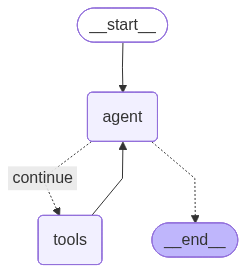

In [26]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [27]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?")]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What's the weather like in Zurich, and what should I wear based on the temperature?
================================== Ai Message ==================================
Tool Calls:
  search_tool (call_tCor5faBUVcofHWC03qaxvNG)
 Call ID: call_tCor5faBUVcofHWC03qaxvNG
  Args:
    query: current weather Zurich
================================= Tool Message =================================
Name: search_tool

[{"title": "Switzerland weather in September 2026 | Weather25.com", "url": "https://www.weather25.com/europe/switzerland?page=month&month=September", "content": "weather25.com\nSearch\nweather in Switzerland\nRemove from your favorite locations\nAdd to my locations\nShare\nweather in Switzerland\n\n# Switzerland weather in September 2026\n\nThe temperatures in Switzerland in September are quite cold with temperatures between 9\u00b0C and 21\u00b0C, warm clothes are a must.\n\nYou can expect about 3 to 8 days